### Mapeando la funcion de probabilidad


\begin{equation}
    p(\widetilde{X}) = p(\widetilde{E})\text{ det }\mathbb{J}_{\varepsilon \widetilde{X}}
\end{equation}

In [1]:
import numpy as np
from Utils import (
    compute_functions, 
    compute_state_vector, 
    Kepler, OrbitTrasformations, 
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_E_to_X, 
    trasformation_X_to_E,
    P_E
    )
import spiceypy as spy
import scipy.optimize as optimize
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import warnings
%load_ext autoreload 
%autoreload 2

In [2]:
cu = CanonicalUnits()
deg = cu.deg
AU_m = cu.AU_m #m
M_sun = cu.M_sun
G = cu.G # m^3 / (kg s^2)
year = cu.year #s
mu = cu.mu
grav_params = GravitationalParameters(mu=mu)

In [3]:
def jacobian_XoE(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> np.array:
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D', 'F', 'G'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    F = functions['F']
    G = functions['G']
    
    ot = OrbitTrasformations()
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_z = state_vector[2]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)
    partial_a_vz = -state_vector[5]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_z, partial_a_vx, partial_a_vy, partial_a_vz]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        drAde*F+drBde*G,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D,
        dvAde*F+dvBde*G
    ])

    #partial i
    partial_i_x = state_vector[2]*np.sin(Omega)
    partial_i_y = -state_vector[2]*np.cos(Omega)
    partial_i_z = -state_vector[0]*np.sin(Omega) + state_vector[1]*np.cos(Omega)

    partial_i_vx = state_vector[5]*np.sin(Omega)
    partial_i_vy = -state_vector[5]*np.cos(Omega)
    partial_i_vz = -state_vector[3]*np.sin(Omega) + state_vector[4]*np.cos(Omega)

    partial_i = [partial_i_x, partial_i_y, partial_i_z, partial_i_vx, partial_i_vy, partial_i_vz]

    #partial Omega
    partial_Omega_x = -state_vector[1]
    partial_Omega_y = state_vector[0]
    partial_Omega_z = 0

    partial_Omega_vx = -state_vector[4]
    partial_Omega_vy = state_vector[3]
    partial_Omega_vz = 0

    partial_Omega = [partial_Omega_x, partial_Omega_y, partial_Omega_z, partial_Omega_vx, partial_Omega_vy, partial_Omega_vz]

    #partial w

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_z = state_vector[0]*np.sin(i)*np.cos(Omega) + state_vector[1]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)
    partial_w_vz = state_vector[3]*np.sin(i)*np.cos(Omega) + state_vector[4]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_z, partial_w_vx, partial_w_vy, partial_w_vz]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_z = (1/n) * state_vector[5]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]
    partial_M_vz = factor * state_vector[2]

    partial_M = [partial_M_x, partial_M_y, partial_M_z, partial_M_vx, partial_M_vy, partial_M_vz]

    J = np.zeros((6,6))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_i
    J[:,3] = partial_Omega
    J[:,4] = partial_w
    J[:,5] = partial_M
    
    return J

In [4]:
a = np.random.uniform(0, 2)
e = np.random.uniform(0, 1)
i = np.random.uniform(0, np.pi)
Omega = np.random.uniform(0, 2*np.pi)
w = np.random.uniform(0, 2*np.pi)
M = np.random.uniform(0, 2*np.pi)
q = a*(1-e)

print('orbital elements: ', a, e, i, Omega, w, M)

orbital elements:  1.5286202767089518 0.8553414336106456 0.5706820513748598 3.5907407650196985 5.956426027926587 1.6936868015266116


In [5]:
x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
print('state vector: ', x, y, z, vx, vy, vz)

state vector:  2.3121336244603077 -0.10280850044295775 0.7039008133551232 2.217688105686452 1.3663640432170412 -0.17199135057758902


In [6]:
def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = jacobian_XoE(a,e,i,Omega,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_E() * abs(det)
    return P

def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    problematic = []
    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = jacobian_XoE(a,e,i,Omega,w,M,mu)
        with np.errstate(divide='ignore', invalid='ignore'):
            det = np.linalg.det(J)
            #print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print(det)
            if det == 0 or not np.isfinite(det):
                problematic.append((x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx]))
                P.flat[idx] = np.nan
            else:
                inv_det = 1.0/det  
                P.flat[idx] = P_E() * abs(inv_det)

    return P.reshape(shape), problematic


In [7]:
P_X(x, y, z, vx, vy, vz)

9.052081253563196e-06

### Evaluating in the integral limits 

In [8]:
xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)


X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

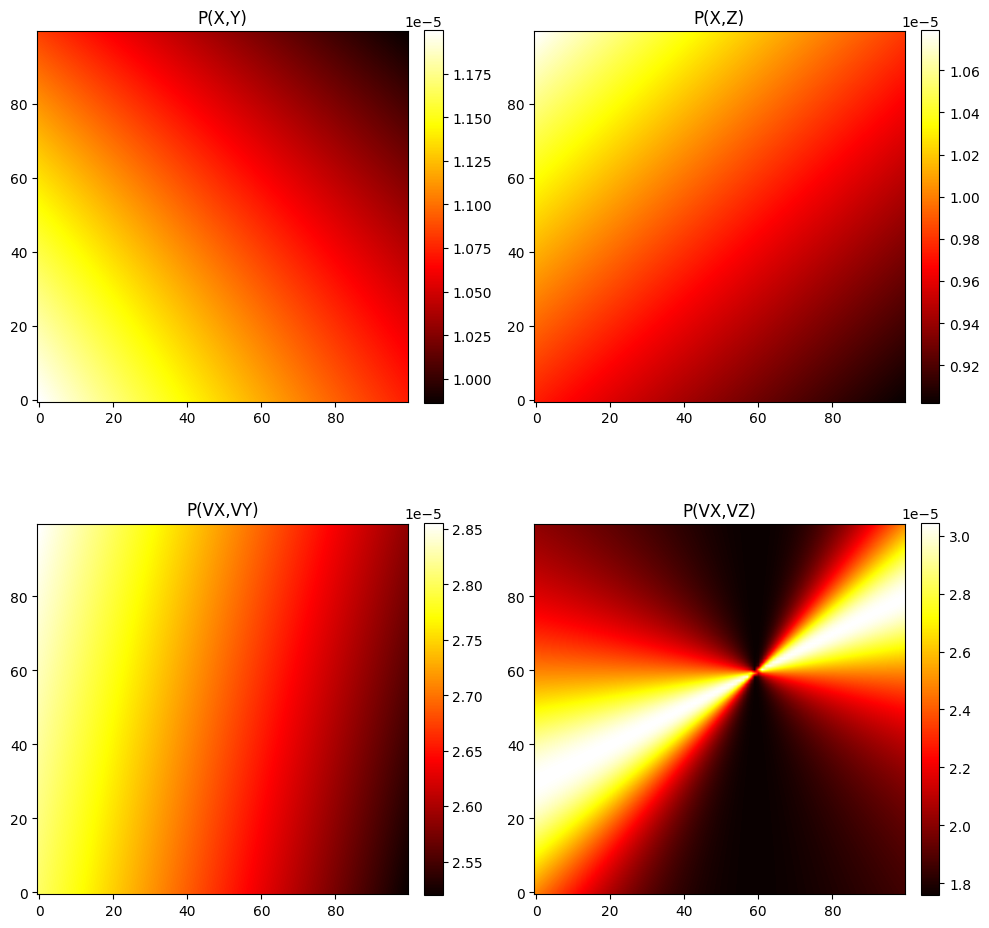

In [9]:
P = [P_XY, P_XZ, P_VXY, P_VXZ]
titles = ["P(X,Y)", "P(X,Z)", "P(VX,VY)", "P(VX,VZ)",]

fig, axes = plt.subplots(2, 2, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(P[i],
                   origin='lower',
                   cmap='hot',
                   interpolation='bilinear')

    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # barra individual

plt.tight_layout()
plt.show()

In [10]:
X = np.linspace(-1, 1, 100)
Y = np.linspace(-1, 1, 100)
Z = np.linspace(-0.2, 0.2, 100)
VX = np.linspace(-5, 5, 100)
VY = np.linspace(-5, 5, 100)
VZ = np.linspace(-0.8, 0.8, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

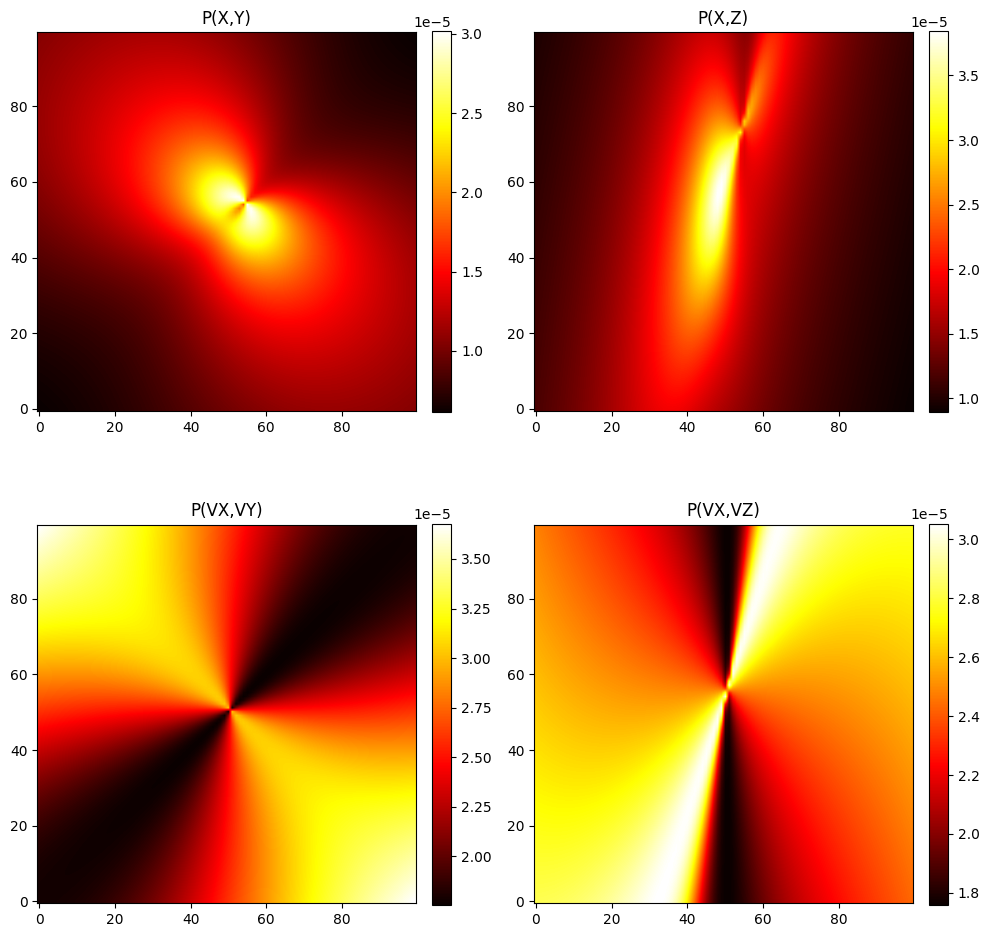

In [11]:
P = [P_XY, P_XZ, P_VXY, P_VXZ]
titles = ["P(X,Y)", "P(X,Z)", "P(VX,VY)", "P(VX,VZ)",]

fig, axes = plt.subplots(2, 2, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(P[i],
                   origin='lower',
                   cmap='hot',
                   interpolation='bilinear')

    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # barra individual

plt.tight_layout()
plt.show()

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:778: RuntimeWarning: divide by zero encountered in scalar divide
  a = q/(1-e)
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:16: RuntimeWarning: invalid value encountered in scalar divide
  nur = nu/r
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:18: RuntimeWarning: invalid value encountered in scalar multiply
  q = a*(1-e)
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:35: RuntimeWarning: invalid value encountered in scalar divide
  dcosEde=-a*np.sin(E)**2/r
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:36: RuntimeWarning: invalid value encountered in scalar divide
  dsinEde=a*np.cos(E)*np.sin(E)/r
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:37: RuntimeWarning: invalid value encountered in scalar divide
  dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
C:\Users\aguju\AppData\Local\Temp\ipykernel_1241

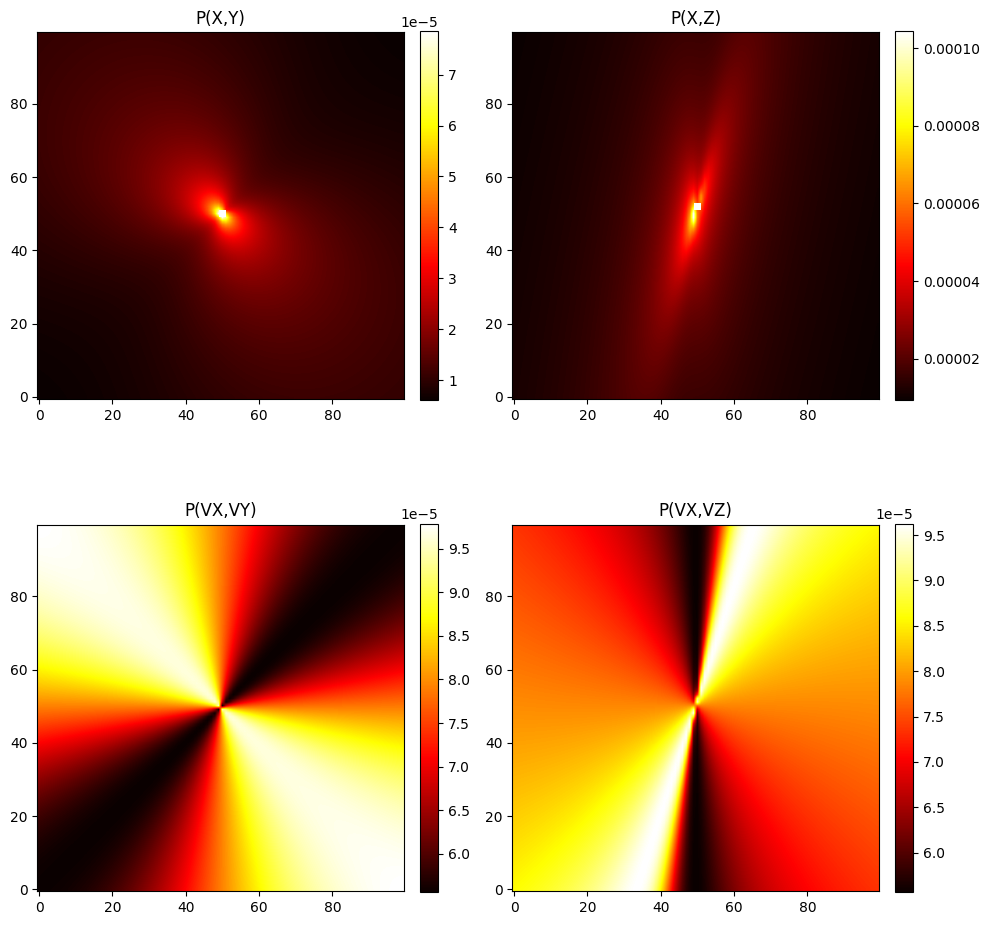

In [12]:
X = np.linspace(-1, 1, 100)
Y = np.linspace(-1, 1, 100)
Z = np.linspace(-0.2, 0.2, 100)
VX = np.linspace(-5, 5, 100)
VY = np.linspace(-5, 5, 100)
VZ = np.linspace(-0.8, 0.8, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.01

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

P = [P_XY, P_XZ, P_VXY, P_VXZ]
titles = ["P(X,Y)", "P(X,Z)", "P(VX,VY)", "P(VX,VZ)",]

fig, axes = plt.subplots(2, 2, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(P[i],
                   origin='lower',
                   cmap='hot',
                   interpolation='bilinear')

    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # barra individual

plt.tight_layout()
plt.show()

C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:16: RuntimeWarning: invalid value encountered in scalar divide
  nur = nu/r
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:18: RuntimeWarning: invalid value encountered in scalar multiply
  q = a*(1-e)
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:35: RuntimeWarning: invalid value encountered in scalar divide
  dcosEde=-a*np.sin(E)**2/r
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:36: RuntimeWarning: invalid value encountered in scalar divide
  dsinEde=a*np.cos(E)*np.sin(E)/r
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:37: RuntimeWarning: invalid value encountered in scalar divide
  dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  depsde=-e/eps
C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\1282213766.py:90: RuntimeW

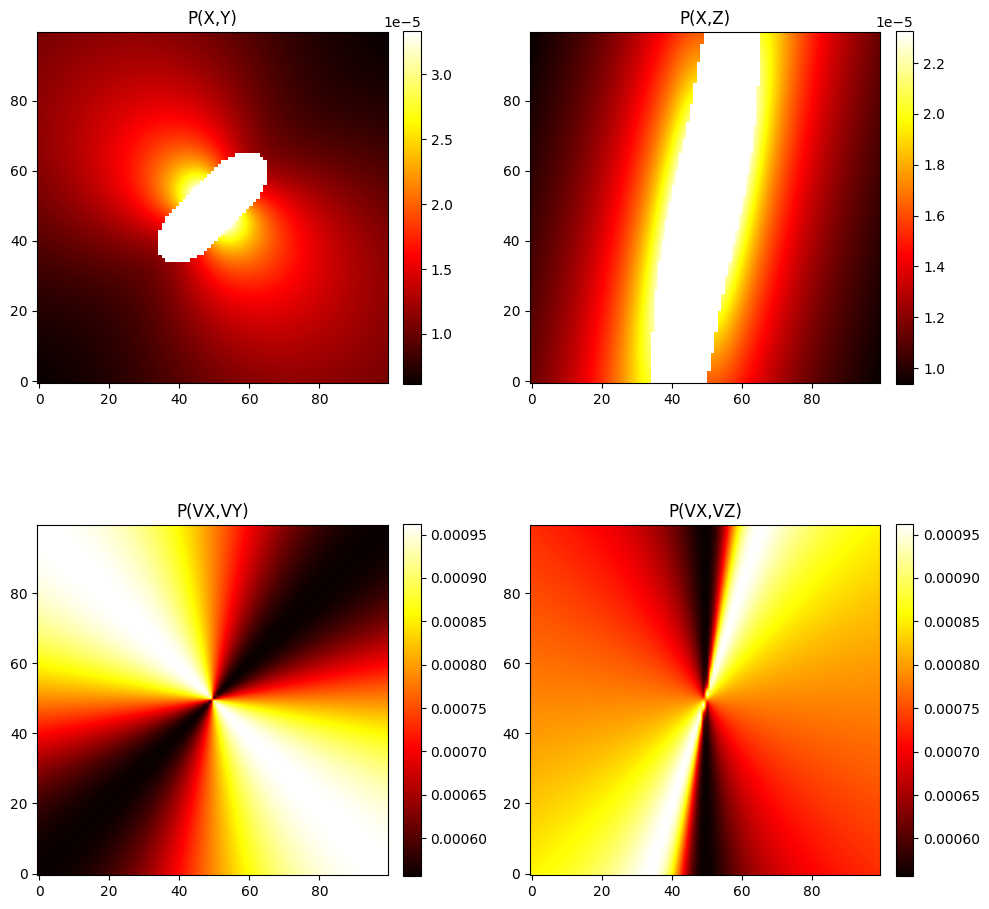

In [13]:
X = np.linspace(-1, 1, 100)
Y = np.linspace(-1, 1, 100)
Z = np.linspace(-0.2, 0.2, 100)
VX = np.linspace(-5, 5, 100)
VY = np.linspace(-5, 5, 100)
VZ = np.linspace(-0.8, 0.8, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.0001

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

P = [P_XY, P_XZ, P_VXY, P_VXZ]
titles = ["P(X,Y)", "P(X,Z)", "P(VX,VY)", "P(VX,VZ)",]

fig, axes = plt.subplots(2, 2, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(P[i],
                   origin='lower',
                   cmap='hot',
                   interpolation='bilinear')

    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # barra individual

plt.tight_layout()
plt.show()

In [22]:
problematic_XZ

[(-0.2929292929292928, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.2727272727272727, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.2525252525252525, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.23232323232323226, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.21212121212121204, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.19191919191919182, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.1717171717171716, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.1515151515151515, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.13131313131313127, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.11111111111111105, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.09090909090909083, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.07070707070707061, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.050505050505050386, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.030303030303030276, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.010101010101010055, 0.0001, -0.2, 0.0001, 0.0001, 0.0001),
 (-0.2929292929292928, 0.0001, -0.19595959595959597, 0.00

In [26]:
weird_asteroid = (-0.2929292929292928, 0.0001, -0.2, 0.0001, 0.0001, 0.0001)
weird_asteroid[0]

-0.2929292929292928

In [28]:
import plotly.graph_objects as go
import numpy as np

weird_asteroid = (-0.2929292929292928, 0.0001, -0.2, 0.0001, 0.0001, 0.0001)
# Create figure
fig = go.Figure()

# Sun (yellow sphere)
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_sun = 8 * np.outer(np.cos(u), np.sin(v))
y_sun = 8 * np.outer(np.sin(u), np.sin(v))
z_sun = 8 * np.outer(np.ones(np.size(u)), np.cos(v))
"""
fig.add_trace(go.Surface(
    x=x_sun, y=y_sun, z=z_sun,
    colorscale=[[0, 'rgb(255,221,0)'], [1, 'rgb(255,170,0)']],
    showscale=False,
    name='Sun',
    hoverinfo='name',
    lighting=dict(ambient=0.9, diffuse=0.9, specular=0.1),
    lightposition=dict(x=0, y=0, z=0)
))
"""
# Earth (blue sphere)
earth_orbit_radius = 50
earth_angle = 0  # Starting position
x_earth = 3 * np.outer(np.cos(u), np.sin(v)) + earth_orbit_radius * np.cos(earth_angle)
y_earth = 3 * np.outer(np.sin(u), np.sin(v)) + earth_orbit_radius * np.sin(earth_angle)
z_earth = 3 * np.outer(np.ones(np.size(u)), np.cos(v))

"""
fig.add_trace(go.Surface(
    x=x_earth, y=y_earth, z=z_earth,
    colorscale=[[0, 'rgb(34,51,255)'], [1, 'rgb(17,34,136)']],
    showscale=False,
    name='Earth',
    hoverinfo='name',
    lighting=dict(ambient=0.6, diffuse=0.7, specular=0.3)
))
"""
# Earth's orbit path
theta = np.linspace(0, 2 * np.pi, 200)
orbit_x = earth_orbit_radius * np.cos(theta)
orbit_y = earth_orbit_radius * np.sin(theta)
orbit_z = np.zeros_like(theta)

fig.add_trace(go.Scatter3d(
    x=orbit_x, y=orbit_y, z=orbit_z,
    mode='lines',
    line=dict(color='rgba(68,102,255,0.3)', width=2),
    name='Earth Orbit',
    hoverinfo='name'
))

# Asteroids (small white dots in asteroid belt)
np.random.seed(42)
n_asteroids = 800

# Generate asteroid positions in a belt
asteroid_radii = 25 + np.random.rand(n_asteroids) * 15
asteroid_angles = np.random.rand(n_asteroids) * 2 * np.pi
asteroid_heights = (np.random.rand(n_asteroids) - 0.5) * 8

asteroid_x = asteroid_radii * np.cos(asteroid_angles)
asteroid_y = asteroid_radii * np.sin(asteroid_angles)
asteroid_z = asteroid_heights

fig.add_trace(go.Scatter3d(
    x=asteroid_x, y=asteroid_y, z=asteroid_z,
    mode='markers',
    marker=dict(
        size=2,
        color='rgba(200,200,200,0.8)',
        symbol='circle'
    ),
    name='Asteroids',
    hoverinfo='name'
))

fig.add_trace(go.Scatter3d(
    x=[weird_asteroid[0]], y=[weird_asteroid[1]], z=[weird_asteroid[2]],
    mode='markers',
    marker=dict(
        size=4,
        color='red',
        symbol='circle'
    ),
    name='Weird Asteroid',
    hoverinfo='name'
))

# Layout with dark background
fig.update_layout(
    title={
        'text': '3D Solar System - Sun, Earth & Asteroids',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 24, 'color': 'white'}
    },
    scene=dict(
        xaxis=dict(
            showbackground=False,
            showgrid=False,
            showticklabels=False,
            title='',
            showspikes=False,
            visible=False
        ),
        yaxis=dict(
            showbackground=False,
            showgrid=False,
            showticklabels=False,
            title='',
            showspikes=False,
            visible=False
        ),
        zaxis=dict(
            showbackground=False,
            showgrid=False,
            showticklabels=False,
            title='',
            showspikes=False,
            visible=False
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2),
            center=dict(x=0, y=0, z=0)
        ),
        aspectmode='data',
        bgcolor='rgb(5,10,20)'
    ),
    paper_bgcolor='rgb(10,15,30)',
    showlegend=True,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(20,20,40,0.8)',
        bordercolor='rgba(100,100,150,0.5)',
        borderwidth=1,
        font=dict(color='white', size=12)
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    width=1200,
    height=800
)

# Show the plot
fig.show()

## Tomar valores en cajas de posicion y velocidad que tengan sentido fisico e ir ampliando ejemplo: x = 1, vx = (0.1, 0.1) vy = 28 km/s - 32 km/s  y sus inversos deberian dar tambien

Hacer rutinas entregables 

Hacer un interactivo de python de barras x, y, z, vx, vy, vz y como se ve eso en orbitas de los planetas

singularidades en el jacobiano??

Hacer que las singularidades (que las definimos desde la fisica) valgan cero para que no contribuyan con la integral 

Preguntarle a chato, a cursor

In [14]:
def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    problematic = []
    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = jacobian_XoE(a,e,i,Omega,w,M,mu)
        with np.errstate(divide='ignore', invalid='ignore'):
            det = np.linalg.det(J)
            print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
            print(det)
            if det == 0 or not np.isfinite(det):
                problematic.append((x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx]))
                P.flat[idx] = np.nan
            else:
                inv_det = 1.0/det  
                P.flat[idx] = P_E() * abs(inv_det)

    return P.reshape(shape), problematic


In [15]:
X = np.linspace(0.8, 1.2, 100)
VY = np.linspace(5.8, 6.2, 100)

X_malla, VY_malla = np.meshgrid(X, VY)
P_XY, problematic = P_X_vectorized(x=X_malla, y=zero_vector + 0.1, z=zero_vector, vx=zero_vector + 0.1, vy=VY_malla + 0.1, vz=zero_vector, mu=mu)


0.8 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.0038828660701486052
0.8040404040404041 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.0038373774635093163
0.8080808080808082 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.003792109459516989
0.8121212121212121 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.003747060613382846
0.8161616161616162 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.0037022295999204536
0.8202020202020203 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.0036576152161775007
0.8242424242424243 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.0036132163843301014
0.8282828282828283 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.0035690321548526847
0.8323232323232324 0.10010000000000001 0.0001 0.10010000000000001 5.8999999999999995 0.0001
0.00352506170

In [16]:
P_XY

array([[0.16524492, 0.16720375, 0.16919973, ..., 0.4783354 , 0.47208076,
        0.46562003],
       [0.16563369, 0.1676032 , 0.1696102 , ..., 0.4751472 , 0.46881654,
        0.46229437],
       [0.16602455, 0.16800482, 0.17002292, ..., 0.47193744, 0.46553671,
        0.45895874],
       ...,
       [0.21504531, 0.21850676, 0.22205391, ..., 0.22701015, 0.22329866,
        0.21967756],
       [0.21571326, 0.21919586, 0.22276478, ..., 0.22540602, 0.22172925,
        0.21814199],
       [0.21638489, 0.21988877, 0.22347958, ..., 0.22381802, 0.22017559,
        0.21662179]])

In [17]:
problematic

[]

In [18]:
def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = jacobian_XoE(a,e,i,Omega,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_E() * abs(det)
    return P

In [19]:
P_X(1.195959595959596, 0.0, 0.0, 0.1, 6.2, 0.0)

C:\Users\aguju\AppData\Local\Temp\ipykernel_12416\3047769587.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  det = 1.0/np.linalg.det(J)


inf